## 0. Config

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader, Subset
import torch.nn as nn
from sklearn.preprocessing import LabelEncoder
import torch.optim as optim
import matplotlib.pyplot as plt
from IPython import display
import copy
import nltk
from collections import Counter
import gensim.downloader as api
import time
from scipy.stats import friedmanchisquare
import scikit_posthocs

In [2]:
random_state = 123
torch.manual_seed(random_state)
np.random.seed(random_state)
pd.options.display.float_format = '{:.4f}'.format
pd.set_option('display.max_colwidth', None)

## 1. Data preparing

In [3]:
df = pd.read_csv("Train_rev1.csv")
print(len(df))
df.head()

244768


,Id,Title,FullDescription,LocationRaw,LocationNormalized,ContractType,ContractTime,Company,Category,SalaryRaw,SalaryNormalized,SourceName
0,12612628,Engineering Systems Analyst,"Engineering Systems Analyst Dorking Surrey Salary ****K Our client is located in Dorking, Surrey and are looking for Engineering Systems Analyst our client provides specialist software development Keywords Mathematical Modelling, Risk Analysis, System Modelling, Optimisation, MISER, PIONEEER Engineering Systems Analyst Dorking Surrey Salary ****K","Dorking, Surrey, Surrey",Dorking,NaN,permanent,Gregory Martin International,Engineering Jobs,20000 - 30000/annum 20-30K,25000,cv-library.co.uk
1,12612830,Stress Engineer Glasgow,"Stress Engineer Glasgow Salary **** to **** We re currently looking for talented engineers to join our growing Glasgow team at a variety of levels. The roles are ideally suited to high calibre engineering graduates with any level of appropriate experience, so that we can give you the opportunity to use your technical skills to provide high quality input to our aerospace projects, spanning both aerostructures and aeroengines. In return, you can expect good career opportunities and the chance for advancement and personal and professional development, support while you gain Chartership and some opportunities to possibly travel or work in other offices, in or outside of the UK. The Requirements You will need to have a good engineering degree that includes structural analysis (such as aeronautical, mechanical, automotive, civil) with some experience in a professional engineering environment relevant to (but not limited to) the aerospace sector. You will need to demonstrate experience in at least one or more of the following areas: Structural/stress analysis Composite stress analysis (any industry) Linear and nonlinear finite element analysis Fatigue and damage tolerance Structural dynamics Thermal analysis Aerostructures experience You will also be expected to demonstrate the following qualities: A strong desire to progress quickly to a position of leadership Professional approach Strong communication skills, written and verbal Commercial awareness Team working, being comfortable working in international teams and self managing PLEASE NOTE SECURITY CLEARANCE IS REQUIRED FOR THIS ROLE Stress Engineer Glasgow Salary **** to ****","Glasgow, Scotland, Scotland",Glasgow,NaN,permanent,Gregory Martin International,Engineering Jobs,25000 - 35000/annum 25-35K,30000,cv-library.co.uk
2,12612844,Modelling and simulation analyst,"Mathematical Modeller / Simulation Analyst / Operational Analyst Basingstoke, Hampshire Up to ****K AAE pension contribution, private medical and dental The opportunity Our client is an independent consultancy firm which has an opportunity for a Data Analyst with 35 years experience. The role will require the successful candidate to demonstrate their ability to analyse a problem and arrive at a solution, with varying levels of data being available. Essential skills Thorough knowledge of Excel and proven ability to utilise this to create powerful decision support models Experience in Modelling and Simulation Techniques, Experience of techniques such as Discrete Event Simulation and/or SD modelling Mathematical/scientific background minimum degree qualified Proven analytical and problem solving skills Self Starter Ability to develop solid working relationships In addition to formal qualifications and experience, the successful candidate will require excellent written and verbal communication skills, be energetic, enterprising and have a determination to succeed. They will be required to build solid working relationships, both internally with colleagues and, most importantly, externally with our clients. They must be comfortable working independently to deliver against challenging client demands. The offices are located in Basingstoke, Hampshire, but our client work for clients worldwide. The successful candidate must therefore

In [72]:
cat_features = ["Category", "Company", "LocationNormalized", "ContractType", "ContractTime"]
text_features = ["FullDescription"]
df_final = df[cat_features + text_features + ["SalaryNormalized"]].copy()
df_final.head()

,Category,Company,LocationNormalized,ContractType,ContractTime,FullDescription,SalaryNormalized
0,Engineering Jobs,Gregory Martin International,Dorking,NaN,permanent,Engineering Systems Analyst Dorking Surrey Sal...,25000
1,Engineering Jobs,Gregory Martin International,Glasgow,NaN,permanent,Stress Engineer Glasgow Salary **** to **** We...,30000
2,Engineering Jobs,Gregory Martin International,Hampshire,NaN,permanent,Mathematical Modeller / Simulation Analyst / O...,30000
3,Engineering Jobs,Gregory Martin International,Surrey,NaN,permanent,Engineering Systems Analyst / Mathematical Mod...,27500
4,Engineering Jobs,Gregory Martin International,Surrey,NaN,permanent,"Pioneer, Miser Engineering Systems Analyst Do...",25000


In [73]:
# handle missing values
print(df_final.isna().sum())
for column in cat_features:
    df_final[column] = df_final[column].fillna("Missing").astype(str)
df_final.head()

Category                   0
Company                32430
LocationNormalized         0
ContractType          179326
ContractTime           63905
FullDescription            0
SalaryNormalized           0
dtype: int64


,Category,Company,LocationNormalized,ContractType,ContractTime,FullDescription,SalaryNormalized
0,Engineering Jobs,Gregory Martin International,Dorking,Missing,permanent,Engineering Systems Analyst Dorking Surrey Sal...,25000
1,Engineering Jobs,Gregory Martin International,Glasgow,Missing,permanent,Stress Engineer Glasgow Salary **** to **** We...,30000
2,Engineering Jobs,Gregory Martin International,Hampshire,Missing,permanent,Mathematical Modeller / Simulation Analyst / O...,30000
3,Engineering Jobs,Gregory Martin International,Surrey,Missing,permanent,Engineering Systems Analyst / Mathematical Mod...,27500
4,Engineering Jobs,Gregory Martin International,Surrey,Missing,permanent,"Pioneer, Miser Engineering Systems Analyst Do...",25000


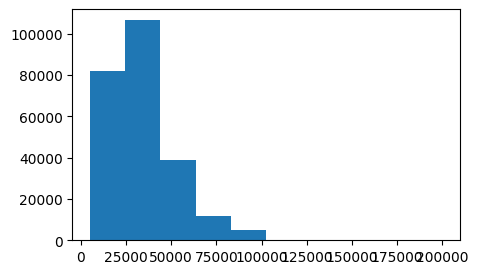

In [74]:
plt.figure(figsize=(5,3))
plt.hist(df_final.SalaryNormalized)
plt.show()

In [75]:
# 80% train, 10% valid, 10% test
x_temp, x_test, y_temp, y_test = train_test_split(df_final.drop("SalaryNormalized", axis=1), np.log1p(df_final.SalaryNormalized), test_size=0.1, random_state=random_state)
x_train, x_valid, y_train, y_valid = train_test_split(x_temp, y_temp, test_size=1/9, random_state=random_state)

In [76]:
# coding categorical variables
vocab_size = []

for col in cat_features:
    unique_cats = x_train[col].unique()
    cat_to_id = {cat: i+1 for i, cat in enumerate(unique_cats)} # 0 - UNK
    vocab_size.append(len(cat_to_id) + 1)
    
    x_train[col] = x_train[col].map(lambda x: cat_to_id.get(x, 0))
    x_valid[col] = x_valid[col].map(lambda x: cat_to_id.get(x, 0))
    x_test[col]  = x_test[col].map(lambda x: cat_to_id.get(x, 0))

In [77]:
x_train_cat, x_valid_cat, x_test_cat = x_train.drop("FullDescription", axis=1), x_valid.drop("FullDescription", axis=1), x_test.drop("FullDescription", axis=1)

## 2. Baseline (only categorical features) 

In [78]:
class JobSalaryDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X.values, dtype=torch.long)
        self.y = torch.tensor(y.values.reshape(-1,1), dtype=torch.float32)

    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
    
train_dataset = JobSalaryDataset(x_train_cat, y_train)
valid_dataset = JobSalaryDataset(x_valid_cat, y_valid)
test_dataset = JobSalaryDataset(x_test_cat, y_test)

In [79]:
# example row
print("x = ", train_dataset[10][0], "\ny = ", train_dataset[10][1])

x =  tensor([ 7, 11,  2,  2,  1]) 
y =  tensor([10.7685])


In [80]:
train_loader_cat = DataLoader(train_dataset, batch_size=64, shuffle=True)
valid_loader_cat = DataLoader(valid_dataset, batch_size=64, shuffle=False)
test_loader_cat = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [81]:
class BaselineModel(nn.Module):
    def __init__(self, vocab_size, emb_dim=16):
        super(BaselineModel, self).__init__()
        
        self.embedding = nn.ModuleList([nn.Embedding(num_embeddings=size, embedding_dim=emb_dim, padding_idx=0) for size in vocab_size])
        input_dim = len(vocab_size) * emb_dim # 5 * 16
        
        self.fc1 = nn.Linear(input_dim, 128)  # (5*16) * 128 + 128
        self.relu1 = nn.ReLU()

        self.fc2 = nn.Linear(128, 64) # 128 * 64 + 64
        self.relu2 = nn.ReLU()

        self.fc3 = nn.Linear(64, 16) # 64 * 16
        self.relu3 = nn.ReLU()

        self.out = nn.Linear(16,1) # 16 * 1 + 1

    def forward(self, x):
        embedding_list = [layer(x[:,i]) for i, layer in enumerate(self.embedding)]
        x = torch.cat(embedding_list, dim = 1)

        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.relu3(self.fc3(x))
        x = self.out(x)
        return x        

In [82]:
def fit(model, train, valid, loss=nn.MSELoss(), epochs=10, patience=3):
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    optimizer = optim.Adam(model.parameters())
    model.to(device)

    # metrics
    train_loss = []
    valid_loss = []
    duration = []

    # early stopping parameters
    patience_count = 0
    best_loss = float('inf')
    best_model = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        start_time = time.time()
        # training
        train_sum_loss = 0
        model.train()
        
        for batch_x, batch_y in train:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            preds = model(batch_x)
            l = loss(preds.view(-1), batch_y.view(-1))
            l.backward()
            optimizer.step()

            train_sum_loss += l.item() * batch_x.size(0)
        train_loss.append(train_sum_loss / len(train.dataset))

        # validation
        model.eval()
        valid_sum_loss = 0.0
        with torch.no_grad():
            for batch_x, batch_y in valid:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                preds = model(batch_x)
                l = loss(preds.view(-1), batch_y.view(-1))
                valid_sum_loss += l.item() * batch_x.size(0)

        valid_loss.append(valid_sum_loss / len(valid.dataset))

        # early stopping
        if valid_loss[-1] < best_loss:
            best_loss = valid_loss[-1]
            patience_count = 0
            best_model = copy.deepcopy(model.state_dict())
        else:
            patience_count += 1

        if patience_count >= patience:
            break

        end_time = time.time()
        duration.append(end_time-start_time)

        # plot
        if epoch > 0:
            display.clear_output(wait=True)
            plt.figure(figsize=(6,4))
            plt.plot(train_loss, label = "train set", color="blue")
            plt.plot(valid_loss, label="valid set", color="orange")
            plt.legend()
            plt.ylabel("loss")
            plt.xlabel("epoch")
            plt.xticks(range(1,epochs+1))
            plt.show()


        print("Epoch",epoch,f"({round(duration[-1],2)}s): Train loss = " , round(train_loss[-1],4),  " Valid loss = ", round(valid_loss[-1],4))
    model.load_state_dict(best_model)

    return best_model, train_loss, valid_loss, duration

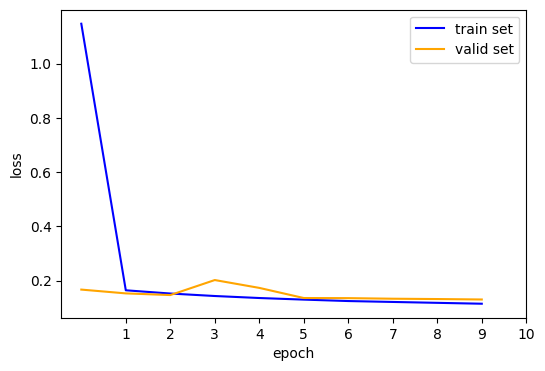

Epoch 9 (2.53s): Train loss =  0.1144  Valid loss =  0.13


In [ ]:
baseline = BaselineModel(vocab_size)
best_baseline, train_loss_baseline, valid_loss_baseline, duration_baseline = fit(baseline, train_loader_cat, valid_loader_cat, epochs=5, patience=4)

In [84]:
print(f"Train loss {np.round(np.array(train_loss_baseline),3)} \nValid loss {np.round(np.array(valid_loss_baseline),3)}")

Train loss [1.147 0.164 0.152 0.143 0.135 0.13  0.124 0.121 0.118 0.114] 
Valid loss [0.166 0.152 0.146 0.202 0.173 0.135 0.135 0.133 0.132 0.13 ]


## 3. Models with a text feature

### 3.1 Self-taught

In [85]:
# tokenization
def preprocess_text(text, word_to_id, max_len):
    tokens = nltk.word_tokenize(text.lower())

    sequence = [word_to_id.get(token, word_to_id['<UNK>']) for token in tokens]

    if len(sequence) < max_len:
        sequence += [0] * (max_len - len(sequence))
    else:
        sequence = sequence[:max_len]
    return sequence

all_tokens = []

for text in x_train.FullDescription:
    all_tokens.extend(nltk.word_tokenize(text.lower()))

word_counts  = Counter(all_tokens)
min_freq = 10
unique_tokens = sorted([word for word,count in word_counts.items() if count >= min_freq])
word_to_id = {word: i+2 for i, word in enumerate(unique_tokens)} # i+2, because 0 is padding and 1 is unknown
word_to_id['<PAD>'] = 0
word_to_id['<UNK>'] = 1

print(len(word_to_id))

33233


In [86]:
# lengths = [len(nltk.word_tokenize(str(text))) for text in x_train.FullDescription]
# np.median(lengths)   # 257

In [87]:
X_text_train = [preprocess_text(t, word_to_id, max_len=300) for t in x_train.FullDescription]
X_text_valid = [preprocess_text(t, word_to_id, max_len=300) for t in x_valid.FullDescription]
X_text_test = [preprocess_text(t, word_to_id, max_len=300) for t in x_test.FullDescription]

In [88]:
class SelfTaughtDataset(Dataset):
    def __init__(self, cat_data, text_data, y):

        self.cat_features = torch.tensor(cat_data.values, dtype=torch.long)
        self.text_feature = torch.tensor(text_data, dtype=torch.long)
        self.y = torch.tensor(y.values.reshape(-1,1), dtype=torch.float32)


    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.cat_features[idx], self.text_feature[idx], self.y[idx]

    
train_dataset = SelfTaughtDataset(x_train[cat_features], X_text_train, y_train)
valid_dataset = SelfTaughtDataset(x_valid[cat_features], X_text_valid, y_valid)
test_dataset = SelfTaughtDataset(x_test[cat_features], X_text_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [89]:
test_dataset[21][1] # example row

tensor([29433, 15784,  2449, 11075, 20989, 29655, 32034, 15211,  2506, 32034,
        31942,     1,   225, 32853, 31834,  3847, 29342, 17944, 22002, 24978,
        12183, 29342, 29292, 31942, 12868,     1, 29655, 14090, 21901, 15580,
        32863, 28996, 15580, 29342, 12611, 32853, 19682, 13702, 13092,  5095,
         8899, 11234,  2980, 31616,  2980, 26857,  3384, 29292, 11234, 29342,
        14673,  5292, 26763, 13702,  1355, 27330,  3546, 14910,  3384, 29292,
          223, 14674, 31952, 11864, 26502, 31942,  1355, 21622, 10320, 20818,
        27292, 23164,  8899,   225, 29407, 26763, 13702,  1074, 32813, 20679,
        11234,   223, 31743, 14953,  3200, 17064,   925, 32813, 31952, 29342,
        27292, 23164, 15072,   225, 29342, 10320, 20679, 29433, 25423, 15784,
        20818, 29342,  3384,  7290, 29292, 20679, 23164, 11685, 14910, 21075,
        29655, 28490,  1355, 19314, 24585,   225, 32778, 15784, 17628, 29804,
         1355, 17976, 32806, 20679, 11189,  2506,  2449, 10839, 

In [90]:
class SelfTaughtModel(nn.Module):
    def __init__(self, cat_vocab_size, text_vocab_size, emb_dim_text = 64, emb_dim_cat=16):
        super(SelfTaughtModel, self).__init__()
        
        self.cat_embeddings = nn.ModuleList([nn.Embedding(num_embeddings=size, embedding_dim=emb_dim_cat, padding_idx=0) for size in cat_vocab_size])
        self.text_embeddings = nn.Embedding(num_embeddings=text_vocab_size, embedding_dim=emb_dim_text, padding_idx=0)

        input_dim = len(cat_vocab_size) * emb_dim_cat + emb_dim_text

        self.fc1 = nn.Linear(input_dim, 128) 
        self.relu1 = nn.ReLU()

        self.fc2 = nn.Linear(128, 64) 
        self.relu2 = nn.ReLU()

        self.fc3 = nn.Linear(64, 16)
        self.relu3 = nn.ReLU()

        self.out = nn.Linear(16,1) 

    def forward(self, x_cat, x_text):
        emb_cat = [layer(x_cat[:,i]) for i,layer in enumerate(self.cat_embeddings)]     # kazdy element list ma wymiar (batch_size=64) x (dim_cat_emb=16), a lista ma 5 elementach.
        emb_cat = torch.cat(emb_cat, dim=1)                                             # sklejamy te 5 elementow obok siebie z listy w jeden dwuwymiarowy tensor o wymiarach (batch_size=64) x (16*5)),czyli robimy to po kolumach, stad wymiar 0 zostawiamy w spokoju a reszte laczymy
        emb_text = self.text_embeddings(x_text)                                         # mamy tu tensor o wymiarach (batch_size=64) * (dlugosc_tesktu_z_opisu=300) * (liczba wymiarow embedingu=64)
        mean_emb_text = torch.mean(emb_text, dim=1)                                     # liczymy srednia po kolumach czyli dla kazdego opisu liczymy srednia i dostajemy (batch_size=64) x (liczba_wymiarow_embedingu=64)
        emb_combined = torch.cat([emb_cat, mean_emb_text], dim=1)                       # laczyny je w poziomie, czyli dostajemy (64 * (80+64))

        x = self.relu1(self.fc1(emb_combined))
        x = self.relu2(self.fc2(x))
        x = self.relu3(self.fc3(x))
        
        return self.out(x)

In [143]:
def fit_text(model, train, valid, loss=nn.MSELoss(), optimizer=None, epochs=15, patience=3):
    
    device = torch.device("cpu" if torch.backends.mps.is_available() else "cpu")
    model = model.to(device)
    if optimizer is None:
        optimizer = optim.Adam(model.parameters())

    # metrics
    train_loss = []
    valid_loss = []
    valid_mae = []
    duration = []

    # early stopping parameters
    patience_count = 0
    best_loss = float('inf')
    best_model = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        start_time = time.time()
        # training
        train_sum_loss = 0
        model.train()
        
        for batch_x_cat, batch_x_text, batch_y in train:
            batch_x_cat, batch_x_text, batch_y = batch_x_cat.to(device), batch_x_text.to(device), batch_y.to(device)
            optimizer.zero_grad()
            preds = model(batch_x_cat, batch_x_text)
            l = loss(preds.view(-1), batch_y.view(-1))
            l.backward()
            optimizer.step()

            train_sum_loss += l.item() * batch_x_cat.size(0)
        train_loss.append(train_sum_loss / len(train.dataset))

        # validation
        model.eval()
        valid_sum_loss = 0.0
        valid_sum_mae = 0.0 
        with torch.no_grad():
            for batch_x_cat, batch_x_text, batch_y in valid:
                batch_x_cat, batch_x_text, batch_y = batch_x_cat.to(device), batch_x_text.to(device), batch_y.to(device)
                preds = model(batch_x_cat, batch_x_text)
                l = loss(preds.view(-1), batch_y.view(-1))
                valid_sum_loss += l.item() * batch_x_cat.size(0)

                preds_no_log = torch.expm1(preds.view(-1))
                y_real = torch.expm1(batch_y.view(-1))
                mae = torch.abs(y_real - preds_no_log).mean() * batch_x_cat.size(0)
                valid_sum_mae += mae.item()

        valid_loss.append(valid_sum_loss / len(valid.dataset))
        valid_mae.append(valid_sum_mae / len(valid.dataset))

        # early stopping
        if valid_loss[-1] < best_loss:
            best_loss = valid_loss[-1]
            patience_count = 0
            best_model = copy.deepcopy(model.state_dict())
        else:
            patience_count += 1

        if patience_count >= patience:
            break

        end_time = time.time()
        duration.append(end_time-start_time)

        # plot
        if epoch > 0:
            display.clear_output(wait=True)
            plt.figure(figsize=(6,4))
            plt.plot(train_loss, label = "train set", color="blue")
            plt.plot(valid_loss, label="valid set", color="orange")
            plt.legend()
            plt.ylabel("loss")
            plt.xlabel("epoch")
            plt.xticks(range(1,epochs+1))
            plt.show()


        print("Epoch",epoch,f"({round(duration[-1],3)}s): Train loss = " , round(train_loss[-1],4),  " Valid loss = ", round(valid_loss[-1],4))
    model.load_state_dict(best_model)

    return model, train_loss, valid_loss, valid_mae, duration

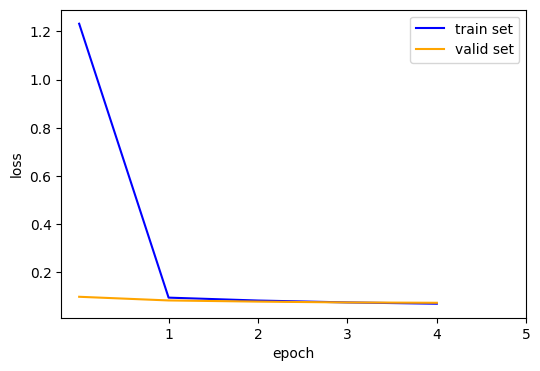

Epoch 4 (9.265s): Train loss =  0.0694  Valid loss =  0.0733


In [144]:
model_st = SelfTaughtModel(vocab_size, len(word_to_id))
model_st, model_sttrain_loss_st, valid_loss_st, valid_mae_st, duration_st = fit_text(model_st, train_loader, valid_loader, epochs=5, patience=4)

### 3.2 Way1 - encode text and usa as a input

In [93]:
wtv_model = api.load('word2vec-google-news-300')

In [94]:
def emb_w2v_google(text_data, w2v_model, dim_emb=300):
    matrix = np.zeros((len(text_data), dim_emb))

    for i, row in enumerate(text_data):
        tokens = nltk.word_tokenize(str(row).lower()) 
        vectors = [w2v_model[word] for word in tokens if word in w2v_model.key_to_index] 

        if len(vectors) > 0:
            matrix[i] = np.mean(vectors, axis=0)
    return matrix

X_train_w2v = emb_w2v_google(x_train.FullDescription, wtv_model)
X_valid_w2v = emb_w2v_google(x_valid.FullDescription, wtv_model)
X_test_w2v = emb_w2v_google(x_test.FullDescription, wtv_model)

In [95]:
train_dataset_w1 = SelfTaughtDataset(x_train[cat_features], X_train_w2v, y_train)
valid_dataset_w1 = SelfTaughtDataset(x_valid[cat_features], X_valid_w2v, y_valid)
test_dataset_w1 = SelfTaughtDataset(x_test[cat_features], X_test_w2v, y_test)

train_loader_w1 = DataLoader(train_dataset_w1, batch_size=64, shuffle=True)
valid_loader_w1 = DataLoader(valid_dataset_w1, batch_size=64, shuffle=False)
test_loader_w1 = DataLoader(test_dataset_w1, batch_size=64, shuffle=False)

In [96]:
class EncodedModel(nn.Module):
    def __init__(self, cat_vocab, cat_emb_dim=16, text_emb_dim=300):
        super(EncodedModel, self).__init__()

        self.cat_emb = nn.ModuleList([nn.Embedding(num_embeddings=size, embedding_dim=cat_emb_dim, padding_idx=0) for size in cat_vocab])

        input_dim = cat_emb_dim * len(cat_vocab) + text_emb_dim

        self.fc1 = nn.Linear(input_dim,128)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(128, 64) 
        self.relu2 = nn.ReLU()

        self.fc3 = nn.Linear(64, 16)
        self.relu3 = nn.ReLU()

        self.out = nn.Linear(16,1) 

    def forward(self, x_cat, x_text):

        cat = [layer(x_cat[:,i]) for i, layer in enumerate(self.cat_emb)]
        cat_tensor = torch.cat(cat, dim=1)
        x = torch.cat([cat_tensor, x_text] ,dim =1)
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.relu3(self.fc3(x))
        
        return self.out(x)

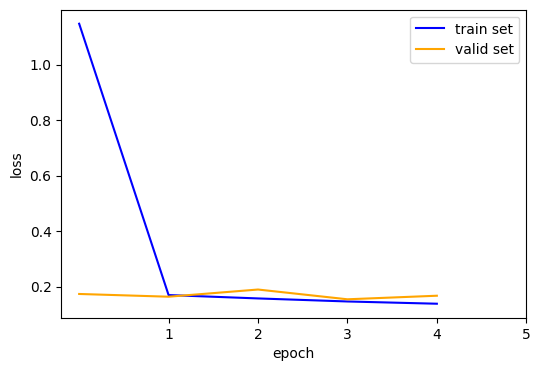

Epoch 4 (3.338s): Train loss =  0.1387  Valid loss =  0.1675


In [145]:
model_way1 = EncodedModel(vocab_size)
model_way1, train_loss_w1, valid_loss_w1, valid_mae_w1, duration_way1 = fit_text(model_way1, train_loader_w1, valid_loader_w1, epochs=5, patience=4)

### 3.3 way2 - include the matrix into the model

In [98]:
# creating a matrix (unique tokens) x (text_emb_dim)
def create_embedding_matrix(word_to_id, w2v_model, emb_dim=300):
    matrix = np.zeros((len(word_to_id), emb_dim))

    for word, idx in word_to_id.items():
        if word in w2v_model:
            matrix[idx] = w2v_model[word]
        elif idx != 0: # for UNK and unseen words we give random values
            matrix[idx] = np.random.normal(scale=0.5 , size=(emb_dim,))
    return matrix

embedding_matrix = create_embedding_matrix(word_to_id, wtv_model)

In [99]:
class Way2And3Model(nn.Module):

    def __init__(self, cat_vocab_size, emb_matrix, freeze_weights, cat_emb_dim=16):
        super(Way2And3Model, self).__init__()

        self.cat_emb = nn.ModuleList([nn.Embedding(num_embeddings=size, embedding_dim=cat_emb_dim, padding_idx=0) for size in cat_vocab_size])
        weights = torch.tensor(emb_matrix, dtype=torch.float32)

        self.text_emb = nn.Embedding.from_pretrained(weights, freeze=freeze_weights)

        input_dim = (cat_emb_dim * len(cat_vocab_size)) + emb_matrix.shape[1]

        self.fc1 = nn.Linear(input_dim, 128)
        self.relu1 = nn.ReLU()

        self.fc2 = nn.Linear(128,64)
        self.relu2 = nn.ReLU()

        self.fc3 = nn.Linear(64,16)
        self.relu3 = nn.ReLU()

        self.out = nn.Linear(16,1)

    def forward(self, cat_data, text_data):
        cats = [layer(cat_data[:,i]) for i, layer in enumerate(self.cat_emb)]           # [batch_size=64, cat_emb_dim=16] x 5, bo mamy 5 kategorii
        cats_combined = torch.cat(cats, dim=1)                                          # laczymy to w poziomie czyli dostajemy [64x(16*5)]

        text_emb = self.text_emb(text_data)                                             # [batch_size=64, liczba_slow_w_opisie=300, wymiar_embedingu_text=300]
        text_flat = torch.mean(text_emb, dim=1)                                         # [batch_size=64,wymiar_embedingu_text=300]

        combined = torch.cat([cats_combined, text_flat], dim=1)                         # [64 x (300+(64*5)]

        x = self.relu1(self.fc1(combined))
        x = self.relu2(self.fc2(x))
        x = self.relu3(self.fc3(x))
        return self.out(x)


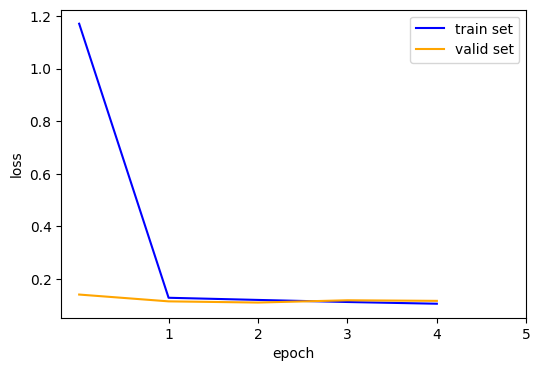

Epoch 4 (6.523s): Train loss =  0.1058  Valid loss =  0.1167


In [146]:
model_way2 = Way2And3Model(vocab_size, embedding_matrix, freeze_weights=True)
model_way2, x_loss_w2, valid_loss_w2, valid_mae_w2, duration_way2 = fit_text(model_way2, train_loader, valid_loader, epochs=5, patience=4)

### 3.4 Way3 - fine-tuning 

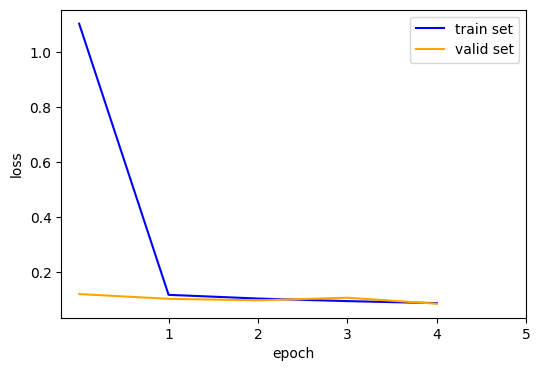

Epoch 4 (29.14s): Train loss =  0.0886  Valid loss =  0.0864


In [147]:
model_way3 = Way2And3Model(vocab_size, embedding_matrix, freeze_weights=False)

model_way3, train_loss_w3, val_loss_w3, val_mae_w3, duration_way3 = fit_text(model_way3, train_loader, valid_loader, optimizer=torch.optim.Adam([{
                                                                                'params': model_way3.text_emb.parameters(), 'lr': 1e-5},
                                                                                {'params': [p for n, p in model_way3.named_parameters() if 'text_emb' not in n], 'lr': 1e-3}]), epochs=5, patience=4)

### 3.5 Self-tought + Conv1d

In [102]:
class SelfTaughtConvModel(nn.Module):
    def __init__(self, cat_vocab_size, text_vocab_size, emb_dim_text = 64, emb_dim_cat=16, conv_out_channels=32, kernel_size=3):
        super(SelfTaughtConvModel, self).__init__()
        
        self.cat_embeddings = nn.ModuleList([nn.Embedding(num_embeddings=size, embedding_dim=emb_dim_cat, padding_idx=0) for size in cat_vocab_size])
        self.text_embeddings = nn.Embedding(num_embeddings=text_vocab_size, embedding_dim=emb_dim_text, padding_idx=0)

        self.conv1 = nn.Conv1d(in_channels=emb_dim_text, out_channels=conv_out_channels, kernel_size=kernel_size, padding=1)
        self.reluconv = nn.ReLU()

        input_dim = len(cat_vocab_size) * emb_dim_cat + conv_out_channels

        self.fc1 = nn.Linear(input_dim, 128) 
        self.relu1 = nn.ReLU()

        self.fc2 = nn.Linear(128, 64) 
        self.relu2 = nn.ReLU()

        self.fc3 = nn.Linear(64, 16)
        self.relu3 = nn.ReLU()

        self.out = nn.Linear(16,1) 

    def forward(self, x_cat, x_text):
        emb_cat = [layer(x_cat[:,i]) for i,layer in enumerate(self.cat_embeddings)]     
        emb_cat = torch.cat(emb_cat, dim=1)  

        emb_text = self.text_embeddings(x_text)   
        emb_text = emb_text.permute(0,2,1)
        conv_text = self.reluconv(self.conv1(emb_text))


        max_conv_text = torch.max(conv_text, dim=2)[0]
        emb_combined = torch.cat([emb_cat, max_conv_text], dim=1)                      

        x = self.relu1(self.fc1(emb_combined))
        x = self.relu2(self.fc2(x))
        x = self.relu3(self.fc3(x))
        
        return self.out(x)

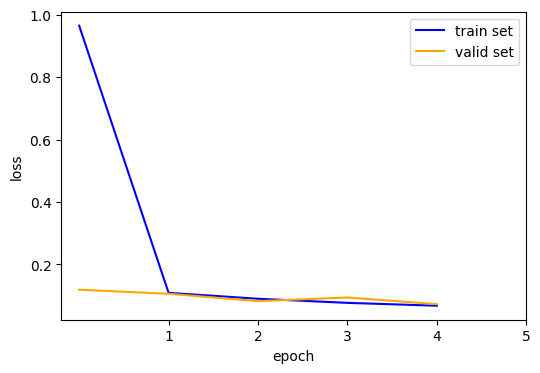

Epoch 4 (75.273s): Train loss =  0.0677  Valid loss =  0.0727


In [148]:
model_st_conv = SelfTaughtConvModel(vocab_size, len(word_to_id))
model_st_conv, train_lost_st_conv, valid_loss_st_conv, valid_mae_st_conv, duration_st_conv = fit_text(model_st_conv, train_loader, valid_loader, epochs=5, patience=4)

### 3.6 Self-taught + ResidualBlock

In [104]:
class ResidualBlock(nn.Module):
    def __init__(self, size):
        super(ResidualBlock, self).__init__()

        self.fc1 = nn.Linear(size, size)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(size,size)

    def forward(self,x):
        y = self.relu1(self.fc1(x))
        y = self.fc2(y)
        return self.relu1(y+x)

In [105]:
class SelfTaughtResModel(nn.Module):
    def __init__(self, cat_vocab_size, text_vocab_size, emb_dim_text=64, emb_dim_cat=16):
        super(SelfTaughtResModel, self).__init__()
        
        self.cat_embeddings = nn.ModuleList([nn.Embedding(num_embeddings=size, embedding_dim=emb_dim_cat, padding_idx=0) for size in cat_vocab_size])
        self.text_embeddings = nn.Embedding(num_embeddings=text_vocab_size, embedding_dim=emb_dim_text, padding_idx=0)

        input_dim = len(cat_vocab_size) * emb_dim_cat + emb_dim_text 

        self.fc1 = nn.Linear(input_dim, 128) 
        self.relu1 = nn.ReLU()

        self.res1 = ResidualBlock(128)

        # Dalej idzie Twoja klasyczna ścieżka
        self.fc2 = nn.Linear(128, 64) 
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(64, 16)
        self.relu3 = nn.ReLU()
        self.out = nn.Linear(16,1) 

    def forward(self, x_cat, x_text):
        # --- Embeddingi i łączenie (bez zmian) ---
        emb_cat = [layer(x_cat[:,i]) for i,layer in enumerate(self.cat_embeddings)]     
        emb_cat = torch.cat(emb_cat, dim=1)                                             
        emb_text = self.text_embeddings(x_text)                                         
        mean_emb_text = torch.mean(emb_text, dim=1)                                     
        emb_combined = torch.cat([emb_cat, mean_emb_text], dim=1)                       

        x = self.relu1(self.fc1(emb_combined))
        
        x = self.res1(x)
        
        x = self.relu2(self.fc2(x))
        x = self.relu3(self.fc3(x))
        
        return self.out(x)

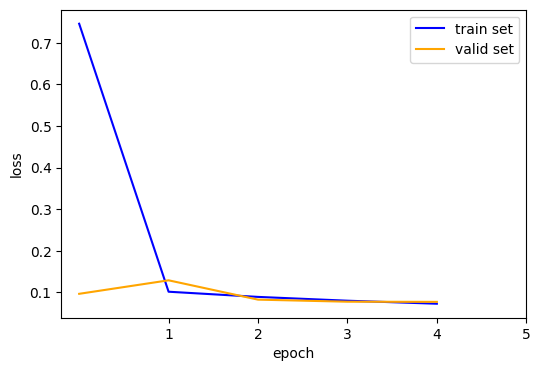

Epoch 4 (9.08s): Train loss =  0.0727  Valid loss =  0.0772


In [149]:
model_st_res = SelfTaughtResModel(vocab_size, len(word_to_id))
model_st_res, train_lost_st_res, valid_loss_st_res, valid_mae_st_res, duration_st_res = fit_text(model_st_res, train_loader, valid_loader, epochs=5, patience=4)

### 3.7 Self-taught + 1xConv + 2xResBlocks

In [107]:
class SelfTaughtRCModel(nn.Module):
    def __init__(self, cat_vocab_size, text_vocab_size, emb_dim_text=64, emb_dim_cat=16, n_out_channels=32):
        super(SelfTaughtRCModel, self).__init__()
        
        self.cat_embeddings = nn.ModuleList([nn.Embedding(num_embeddings=size, embedding_dim=emb_dim_cat, padding_idx=0) for size in cat_vocab_size])
        self.text_embeddings = nn.Embedding(num_embeddings=text_vocab_size, embedding_dim=emb_dim_text, padding_idx=0)

        self.conv1 = nn.Conv1d(in_channels=emb_dim_text, out_channels=n_out_channels, kernel_size=3, padding=1)
        self.reluconv = nn.ReLU()

        input_dim = len(cat_vocab_size) * emb_dim_cat + n_out_channels

        self.fc1 = nn.Linear(input_dim, 128) 
        self.relu1 = nn.ReLU()

        self.res1 = ResidualBlock(128) 
        self.res2 = ResidualBlock(128)
        
        self.out = nn.Linear(128,1) 

    def forward(self, x_cat, x_text):

        emb_cat = [layer(x_cat[:,i]) for i,layer in enumerate(self.cat_embeddings)]     
        emb_cat = torch.cat(emb_cat, dim=1)                                             
        emb_text = self.text_embeddings(x_text) 
        emb_text = emb_text.permute(0,2,1)  
        conv_text = self.conv1(emb_text)

        max_emb_text = torch.max(self.reluconv(conv_text), dim=2)[0]                                     
        emb_combined = torch.cat([emb_cat, max_emb_text], dim=1)                       

        x = self.relu1(self.fc1(emb_combined))
        
        x = self.res1(x)
        x = self.res2(x)
        
        return self.out(x)

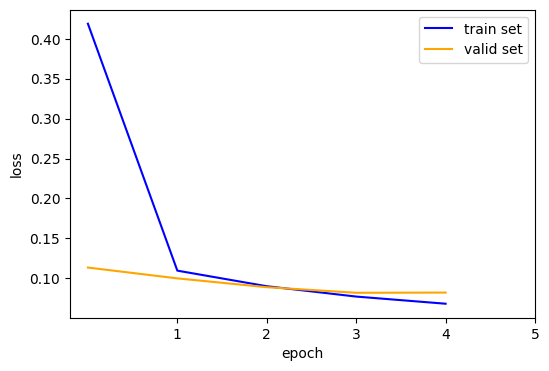

Epoch 4 (76.243s): Train loss =  0.0682  Valid loss =  0.0822


In [150]:
model_st_conv_res = SelfTaughtRCModel(vocab_size, len(word_to_id))
model_st_conv_res, train_lost_st_c_2r, valid_loss_st_2r, valid_mae_st_2r, duration_st_conv_res = fit_text(model_st_conv_res, train_loader, valid_loader, epochs=5, patience=4)

### 3.8 Self-taught + 3xResBlocks

In [109]:
class SelfTaughtResRModel(nn.Module):
    def __init__(self, cat_vocab_size, text_vocab_size, emb_dim_text=64, emb_dim_cat=16):
        super(SelfTaughtResRModel, self).__init__()
        
        self.cat_embeddings = nn.ModuleList([nn.Embedding(num_embeddings=size, embedding_dim=emb_dim_cat, padding_idx=0) for size in cat_vocab_size])
        self.text_embeddings = nn.Embedding(num_embeddings=text_vocab_size, embedding_dim=emb_dim_text, padding_idx=0)

        input_dim = len(cat_vocab_size) * emb_dim_cat + emb_dim_text 

        self.fc1 = nn.Linear(input_dim, 256) 
        self.relu1 = nn.ReLU()

        self.res1 = ResidualBlock(256) 
        self.res2 = ResidualBlock(256)
        self.res3 = ResidualBlock(256)


        self.fc2 = nn.Linear(256, 64) 
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(64, 16)
        self.relu3 = nn.ReLU()
        self.out = nn.Linear(16,1) 

    def forward(self, x_cat, x_text):
        emb_cat = [layer(x_cat[:,i]) for i,layer in enumerate(self.cat_embeddings)]     
        emb_cat = torch.cat(emb_cat, dim=1)                                             
        emb_text = self.text_embeddings(x_text)                                         
        mean_emb_text = torch.mean(emb_text, dim=1)                                     
        emb_combined = torch.cat([emb_cat, mean_emb_text], dim=1)                       

        x = self.relu1(self.fc1(emb_combined))
        
        x = self.res1(x)
        x = self.res2(x)
        x = self.res3(x)
        
        x = self.relu2(self.fc2(x))
        x = self.relu3(self.fc3(x))
        
        return self.out(x)

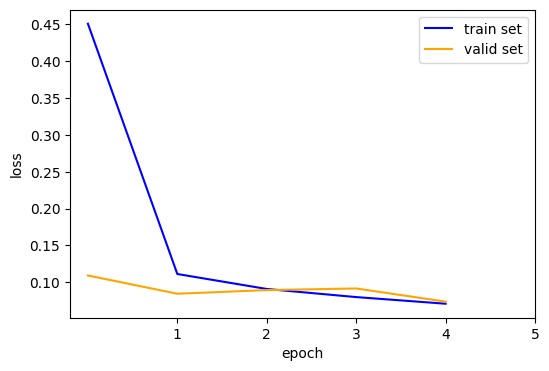

Epoch 4 (12.987s): Train loss =  0.0709  Valid loss =  0.0737


In [151]:
model_st_res3 = SelfTaughtResRModel(vocab_size, len(word_to_id))
model_st_res3, train_lost_res3, valid_loss_res3, valid_mae_res3, duration_st_res3 = fit_text(model_st_res3, train_loader, valid_loader, epochs=5, patience=4)

### 3.9 Way3 - droput + 4xres

In [111]:
class Way3Model4RD(nn.Module):

    def __init__(self, cat_vocab_size, emb_matrix, freeze_weights, cat_emb_dim=16):
        super(Way3Model4RD, self).__init__()

        self.cat_emb = nn.ModuleList([nn.Embedding(num_embeddings=size, embedding_dim=cat_emb_dim, padding_idx=0) for size in cat_vocab_size])
        weights = torch.tensor(emb_matrix, dtype=torch.float32)
        self.text_emb = nn.Embedding.from_pretrained(weights, freeze=freeze_weights)

        self.dropout = nn.Dropout(0.25)

        input_dim = (cat_emb_dim * len(cat_vocab_size)) + weights.shape[1]

        self.fc1 = nn.Linear(input_dim, 128)
        self.relu1 = nn.ReLU()

        self.res1 = ResidualBlock(128)
        self.res2 = ResidualBlock(128)
        self.res3 = ResidualBlock(128)
        self.res4 = ResidualBlock(128)

        self.fc2 = nn.Linear(128,64)
        self.relu2 = nn.ReLU()

        self.fc3 = nn.Linear(64,16)
        self.relu3 = nn.ReLU()

        self.out = nn.Linear(16,1)

    def forward(self, cat_data, text_data):
        cats = [layer(cat_data[:,i]) for i, layer in enumerate(self.cat_emb)] # [batch_size=64, cat_emb_dim=16] x 5, bo mamy 5 kategorii
        cats_combined = torch.cat(cats, dim=1) # laczymy to w poziomie czyli dostajemy [64x(16*5)]

        emb_text = self.text_emb(text_data) # [batch_size=64, liczba_slow_w_opisie=300, wymiar_embedingu_text=300]
        text_flat = torch.mean(emb_text, dim=1) # [batch_size=64,wymiar_embedingu_text=300]

        combined = torch.cat([cats_combined, text_flat], dim=1) # [64 x (300+(64*5)]
        combined = self.dropout(combined)

        x = self.relu1(self.fc1(combined))
        x = self.res1(x)
        x = self.res2(x)
        x = self.res3(x)
        x = self.res4(x)
        x = self.relu2(self.fc2(x))
        x = self.relu3(self.fc3(x))
        return self.out(x)


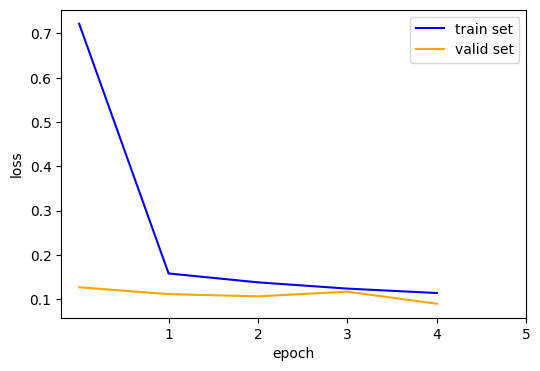

Epoch 4 (31.809s): Train loss =  0.1141  Valid loss =  0.0899


In [152]:
model_way3_4r_d = Way3Model4RD(vocab_size, embedding_matrix, freeze_weights=False)

model_way3_4r_d, train_loss_4d_d, val_loss_4r_d, val_mae_4r_d, duration_way3_4r_d = fit_text(model_way3_4r_d, train_loader, valid_loader, optimizer=torch.optim.Adam([{
                                                                                'params': model_way3_4r_d.text_emb.parameters(), 'lr': 1e-5},
                                                                                {'params': [p for n, p in model_way3_4r_d.named_parameters() if 'text_emb' not in n], 'lr': 1e-3}]), epochs=5, patience=4)

### 3.9 Way3 - Brach + residuals blocks

In [113]:
class ResidualBlockBatch(nn.Module):
    def __init__(self, size):
        super(ResidualBlockBatch, self).__init__()
        self.fc1 = nn.Linear(size, size)
        self.bn1 = nn.BatchNorm1d(size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(size, size)
        self.bn2 = nn.BatchNorm1d(size)

    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.fc1(x)))
        out = self.bn2(self.fc2(out))
        out += identity
        return self.relu(out)

In [114]:
class Way3ModelBatch(nn.Module):
    def __init__(self, cat_vocab_size, emb_matrix, freeze_weights, cat_emb_dim=16):
        super(Way3ModelBatch, self).__init__()

        # Embeddingi
        self.cat_emb = nn.ModuleList([nn.Embedding(num_embeddings=size, embedding_dim=cat_emb_dim, padding_idx=0) for size in cat_vocab_size])
        weights = torch.tensor(emb_matrix, dtype=torch.float32)
        self.text_emb = nn.Embedding.from_pretrained(weights, freeze=freeze_weights)

        self.dropout = nn.Dropout(0.25)
        input_dim = (cat_emb_dim * len(cat_vocab_size)) + weights.shape[1]

        # Warstwy z BatchNorm
        self.bn_input = nn.BatchNorm1d(input_dim) # Normalizacja połączonych embeddingów
        
        self.fc1 = nn.Linear(input_dim, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.relu1 = nn.ReLU()

        self.res1 = ResidualBlockBatch(128)
        self.res2 = ResidualBlockBatch(128)

        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.relu2 = nn.ReLU()

        self.fc3 = nn.Linear(64, 16)
        self.bn3 = nn.BatchNorm1d(16)
        self.relu3 = nn.ReLU()

        self.out = nn.Linear(16, 1)

    def forward(self, cat_data, text_data):
        # Processing embeddings
        cats = [layer(cat_data[:, i]) for i, layer in enumerate(self.cat_emb)]
        cats_combined = torch.cat(cats, dim=1)

        emb_text = self.text_emb(text_data)
        text_flat = torch.mean(emb_text, dim=1)

        # Łączenie i pierwsza normalizacja
        combined = torch.cat([cats_combined, text_flat], dim=1)
        combined = self.bn_input(combined) # Bardzo ważne: stabilizuje skale różnych źródeł danych
        combined = self.dropout(combined)

        # Przepływ przez warstwy
        x = self.relu1(self.bn1(self.fc1(combined)))
        x = self.res1(x)
        x = self.res2(x)
        x = self.relu2(self.bn2(self.fc2(x)))
        x = self.relu3(self.bn3(self.fc3(x)))
        
        return self.out(x)

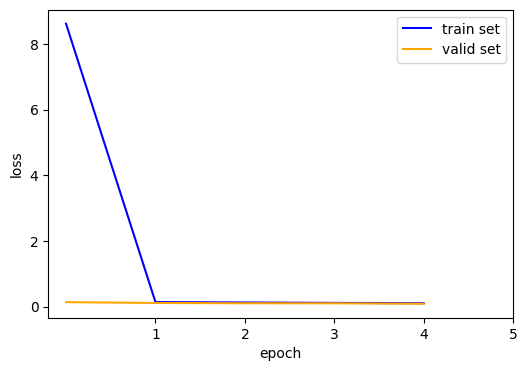

Epoch 4 (33.013s): Train loss =  0.1058  Valid loss =  0.0893


In [115]:
model_way3_batch = Way3ModelBatch(vocab_size, embedding_matrix, freeze_weights=False)

model_way3_batch, train_loss_w3_batch_d, val_loss_batch_d, val_mae_batch_d, duration_way3_batch = fit_text(model_way3_batch, train_loader, valid_loader, optimizer=torch.optim.Adam([{
                                                                                'params': model_way3_batch.text_emb.parameters(), 'lr': 1e-5},
                                                                                {'params': [p for n, p in model_way3_batch.named_parameters() if 'text_emb' not in n], 'lr': 1e-3}]), epochs=5, patience=4)

### 3.10 Way3 & Way2 - conv + residuals blocks

In [116]:
class Way2And3ModelConv(nn.Module):
    def __init__(self, cat_vocab_size, emb_matrix, freeze_weights, cat_emb_dim=16, conv_filters=16):
        super(Way2And3ModelConv, self).__init__()

        self.cat_emb = nn.ModuleList([nn.Embedding(num_embeddings=size, embedding_dim=cat_emb_dim, padding_idx=0) for size in cat_vocab_size])
        
        weights = torch.tensor(emb_matrix, dtype=torch.float32)
        self.text_emb = nn.Embedding.from_pretrained(weights, freeze=freeze_weights)
        text_dim = weights.shape[1] 

        self.fc0 = nn.Linear(text_dim, 50) # to make learning proccess faster
        self.conv1 = nn.Conv1d(in_channels=50, out_channels=conv_filters, kernel_size=3, padding=1)
        self.relu_conv = nn.ReLU()
        
        self.global_pool = nn.AdaptiveMaxPool1d(1)

        input_dim = (cat_emb_dim * len(cat_vocab_size)) + conv_filters

        self.fc1 = nn.Linear(input_dim, 128)
        self.relu1 = nn.ReLU()
        self.res2 = ResidualBlockBatch(128)
        self.res22 = ResidualBlockBatch(128)

        self.fc3 = nn.Linear(128, 16)
        self.relu3 = nn.ReLU()
        self.out = nn.Linear(16, 1)

    def forward(self, cat_data, text_data):
        cats = [layer(cat_data[:, i]) for i, layer in enumerate(self.cat_emb)]
        cats_combined = torch.cat(cats, dim=1)

        text_features = self.text_emb(text_data) 
        text_features = self.fc0(text_features)
        
        text_features = text_features.permute(0, 2, 1) # [64, 300, 300]
        
        x_text = self.relu_conv(self.conv1(text_features))
        
        x_text = self.global_pool(x_text).squeeze(-1) # [Batch, conv_filters]

        combined = torch.cat([cats_combined, x_text], dim=1)

        x = self.relu1(self.fc1(combined))
        x = self.res2(x)
        x = self.res22(x)
        x = self.relu3(self.fc3(x))
        return self.out(x)

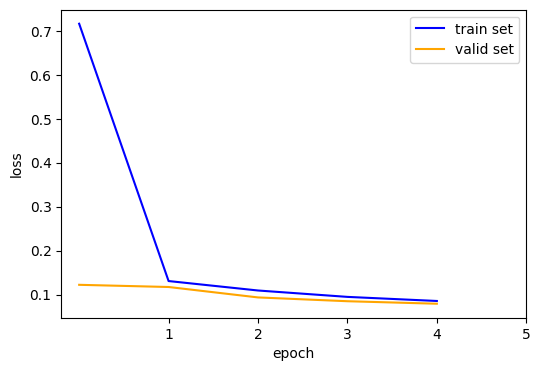

Epoch 4 (751.411s): Train loss =  0.0856  Valid loss =  0.0794


In [117]:
model_way3_conv_res = Way2And3ModelConv(vocab_size, embedding_matrix, freeze_weights=False)

model_way3_conv_res, train_loss_w3_conv_res, val_loss_w3_conv_res, val_mae_w3_conv_res, duration_way3_conv_res = fit_text(model_way3_conv_res, train_loader, valid_loader, optimizer=torch.optim.Adam([{
                                                                                'params': model_way3_conv_res.text_emb.parameters(), 'lr': 1e-5},
                                                                                {'params': [p for n, p in model_way3_conv_res.named_parameters() if 'text_emb' not in n], 'lr': 1e-3}]), epochs=5, patience=4)

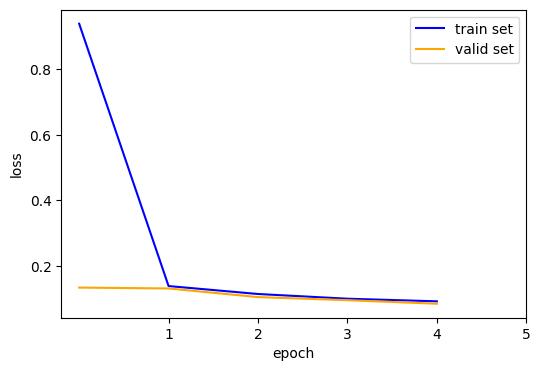

Epoch 4 (64.04s): Train loss =  0.092  Valid loss =  0.0847


In [118]:
model_way2_conv_rest = Way2And3ModelConv(vocab_size, embedding_matrix, freeze_weights=True)

model_way2_conv_rest, train_loss_w2_conv_rest, val_loss_w2_conv_rest, val_mae_w2_conv_rest, duration_way2_conv_rest = fit_text(model_way2_conv_rest, train_loader, valid_loader, epochs=5, patience=4)

### 3.11 Way3 & Way2 - attention pooling

In [119]:
class AttentionPooling(nn.Module):
    def __init__(self, emb_dim):
        super(AttentionPooling, self).__init__()
        self.attention_weights = nn.Sequential(nn.Linear(emb_dim, emb_dim // 2), nn.Tanh(), nn.Linear(emb_dim // 2, 1))

    def forward(self, x):
        
        scores = self.attention_weights(x)
        weights = torch.softmax(scores, dim=1)
        weighted_output = torch.sum(x * weights, dim=1)

        return weighted_output

In [120]:
class Way3And2Att(nn.Module):
    def __init__(self, cat_vocab_size, emb_matrix, freeze_weights, cat_emb_dim=16):
        super(Way3And2Att, self).__init__()

        self.cat_emb = nn.ModuleList([nn.Embedding(num_embeddings=size, embedding_dim=cat_emb_dim, padding_idx=0) for size in cat_vocab_size])
        weights = torch.tensor(emb_matrix, dtype=torch.float32)
        self.text_emb = nn.Embedding.from_pretrained(weights, freeze=freeze_weights)
        text_dim = weights.shape[1]

        self.attention = AttentionPooling(text_dim)

        self.dropout = nn.Dropout(0.25)
        input_dim = (cat_emb_dim * len(cat_vocab_size)) + text_dim

        self.bn_input = nn.BatchNorm1d(input_dim)
        
        self.fc1 = nn.Linear(input_dim, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.relu1 = nn.ReLU()

        self.res1 = ResidualBlockBatch(128)
        self.res2 = ResidualBlockBatch(128)

        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.relu2 = nn.ReLU()

        self.fc3 = nn.Linear(64, 16)
        self.bn3 = nn.BatchNorm1d(16)
        self.relu3 = nn.ReLU()

        self.out = nn.Linear(16, 1)

    def forward(self, cat_data, text_data):
        cats = [layer(cat_data[:, i]) for i, layer in enumerate(self.cat_emb)]
        cats_combined = torch.cat(cats, dim=1)

        emb_text = self.text_emb(text_data) 
        text_flat = self.attention(emb_text) 

        combined = torch.cat([cats_combined, text_flat], dim=1)
        x = self.bn_input(combined)
        x = self.dropout(x)
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.res1(x)
        x = self.res2(x)
        x = self.fc2(x)  
        x = self.bn2(x)   
        x = self.relu2(x)
        x = self.fc3(x) 
        x = self.bn3(x)  
        x = self.relu3(x)
        
        return self.out(x)

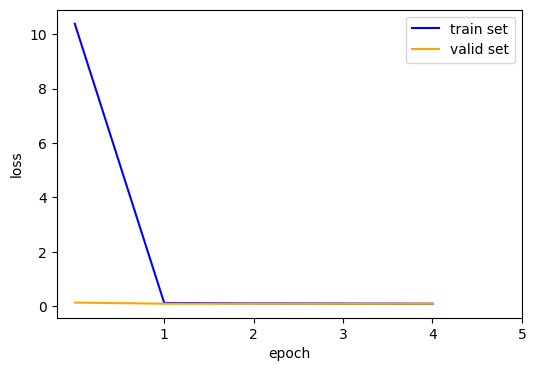

Epoch 4 (73.618s): Train loss =  0.0919  Valid loss =  0.0938


In [153]:
model_way3_att= Way3And2Att(vocab_size, embedding_matrix, freeze_weights=False)

model_way3_att, train_loss_w3_att, val_loss_w3_att, val_mae_w3_att, duration_way3_att = fit_text(model_way3_att, train_loader, valid_loader, optimizer=torch.optim.Adam([{
                                                                                'params': model_way3_att.text_emb.parameters(), 'lr': 1e-5},
                                                                                {'params': [p for n, p in model_way3_att.named_parameters() if 'text_emb' not in n], 'lr': 1e-3}]), epochs=5, patience=4)

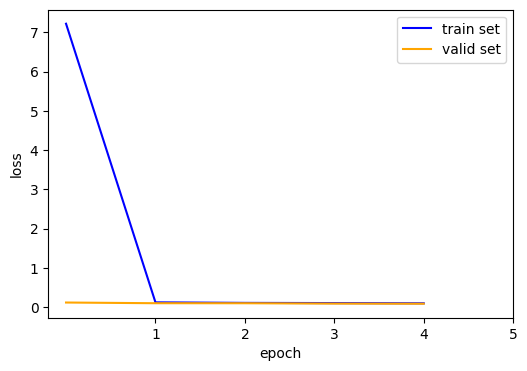

Epoch 4 (41.302s): Train loss =  0.0948  Valid loss =  0.084


In [154]:
model_way2_att= Way3And2Att(vocab_size, embedding_matrix, freeze_weights=True)

model_way2_att, train_loss_w2_att, val_loss_w2_att, val_mae_w2_att, duration_way2_att = fit_text(model_way2_att, train_loader, valid_loader, optimizer=torch.optim.Adam([{
                                                                                'params': model_way2_att.text_emb.parameters(), 'lr': 1e-5},
                                                                                {'params': [p for n, p in model_way2_att.named_parameters() if 'text_emb' not in n], 'lr': 1e-3}]), epochs=5, patience=4)

### 3.12 Way1 with eliminating the rare words

In [124]:
allowed_words = set(wtv_model.key_to_index.keys()).intersection(set(unique_tokens))

def emb_w2v_google_rare(text_data, w2v_model, valid_words, dim_emb=300):
    matrix = np.zeros((len(text_data), dim_emb))

    for i, row in enumerate(text_data):
        tokens = nltk.word_tokenize(str(row).lower()) 
        vectors = [w2v_model[word] for word in tokens if word in valid_words] 
        if vectors:
            matrix[i] = np.mean(vectors, axis=0)
            
    return matrix

# Wywołanie funkcji z nowym argumentem:
X_train_w2v_rare = emb_w2v_google_rare(x_train.FullDescription, wtv_model, allowed_words)
X_valid_w2v_rare = emb_w2v_google_rare(x_valid.FullDescription, wtv_model, allowed_words)
X_test_w2v_rare = emb_w2v_google_rare(x_test.FullDescription, wtv_model, allowed_words)

train_dataset_w1_rare = SelfTaughtDataset(x_train[cat_features], X_train_w2v_rare, y_train)
valid_dataset_w1_rare = SelfTaughtDataset(x_valid[cat_features], X_valid_w2v_rare, y_valid)
test_dataset_w1_rare = SelfTaughtDataset(x_test[cat_features], X_test_w2v_rare, y_test)

train_loader_w1_rare = DataLoader(train_dataset_w1_rare, batch_size=64, shuffle=True)
valid_loader_w1_rare = DataLoader(valid_dataset_w1_rare, batch_size=64, shuffle=False)
test_loader_w1_rare = DataLoader(test_dataset_w1_rare, batch_size=64, shuffle=False)

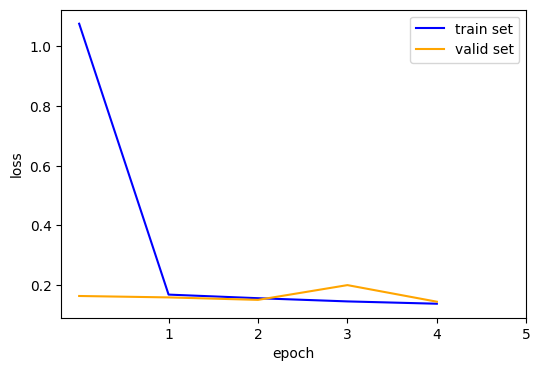

Epoch 4 (3.186s): Train loss =  0.1378  Valid loss =  0.1445


In [155]:
model_way1_rare = EncodedModel(vocab_size)
model_way1_rare, train_loss_w1_rare, valid_loss_w1_rare, valid_mae_w1_rare, duration_way1_rare = fit_text(model_way1_rare, train_loader_w1_rare, valid_loader_w1_rare, epochs=5, patience=4)

### 3.13 Way1 with eliminating the rare words

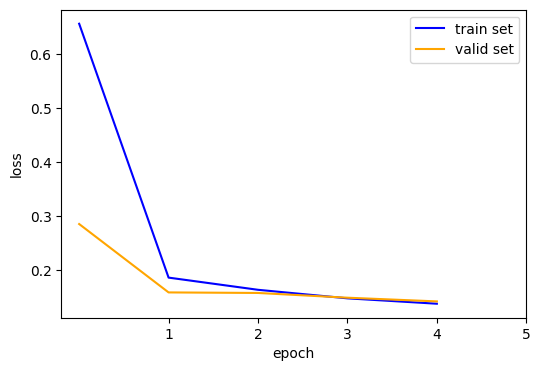

Epoch 4 (4.791s): Train loss =  0.1376  Valid loss =  0.1419


In [156]:
class EncodedModel_3r(nn.Module):
    def __init__(self, cat_vocab, cat_emb_dim=16, text_emb_dim=300):
        super(EncodedModel_3r, self).__init__()

        self.cat_emb = nn.ModuleList([nn.Embedding(num_embeddings=size, embedding_dim=cat_emb_dim, padding_idx=0) for size in cat_vocab])

        input_dim = cat_emb_dim * len(cat_vocab) + text_emb_dim

        self.fc1 = nn.Linear(input_dim,128)
        self.relu1 = nn.ReLU()

        self.res1 = ResidualBlock(128)
        self.res2 = ResidualBlock(128)
        self.res3 = ResidualBlock(128)

        self.fc2 = nn.Linear(128, 64) 
        self.relu2 = nn.ReLU()

        self.fc3 = nn.Linear(64, 16)
        self.relu3 = nn.ReLU()

        self.out = nn.Linear(16,1) 

    def forward(self, x_cat, x_text):

        cat = [layer(x_cat[:,i]) for i, layer in enumerate(self.cat_emb)]
        cat_tensor = torch.cat(cat, dim=1)
        x = torch.cat([cat_tensor, x_text] ,dim =1)
        x = self.relu1(self.fc1(x))
        x = self.res1(x)
        x = self.res2(x)
        x = self.res3(x)
        x = self.relu2(self.fc2(x))
        x = self.relu3(self.fc3(x))
        
        return self.out(x)
    
model_way1_rare_3r = EncodedModel_3r(vocab_size)
model_way1_rare_3r, train_loss_w1_rare_3r, valid_loss_w1_rare_3r, valid_mae_w1_rare_3r, duration_way1_rare_3r = fit_text(model_way1_rare_3r, train_loader_w1_rare, valid_loader_w1_rare, epochs=5, patience=4)

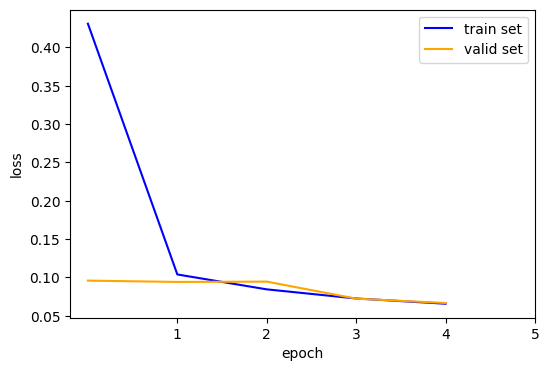

Epoch 4 (17.137s): Train loss =  0.0657  Valid loss =  0.0666


In [130]:
class SelfTaught6R(nn.Module):
    def __init__(self, cat_vocab_size, text_vocab_size, emb_dim_text=64, emb_dim_cat=16):
        super(SelfTaught6R, self).__init__()
        
        self.cat_embeddings = nn.ModuleList([nn.Embedding(num_embeddings=size, embedding_dim=emb_dim_cat, padding_idx=0) for size in cat_vocab_size])
        self.text_embeddings = nn.Embedding(num_embeddings=text_vocab_size, embedding_dim=emb_dim_text, padding_idx=0)

        input_dim = len(cat_vocab_size) * emb_dim_cat + emb_dim_text 

        self.fc1 = nn.Linear(input_dim, 256) 
        self.relu1 = nn.ReLU()

        self.res1 = ResidualBlock(256) 
        self.res2 = ResidualBlock(256)
        self.res3 = ResidualBlock(256)
        self.res4 = ResidualBlock(256) 
        self.res5 = ResidualBlock(256)


        self.fc2 = nn.Linear(256, 128) 
        self.relu2 = nn.GELU()
        self.fc3 = nn.Linear(128, 32)
        self.relu3 = nn.GELU()
        self.out = nn.Linear(32,1) 

    def forward(self, x_cat, x_text):
        emb_cat = [layer(x_cat[:,i]) for i,layer in enumerate(self.cat_embeddings)]     
        emb_cat = torch.cat(emb_cat, dim=1)                                             
        emb_text = self.text_embeddings(x_text)                                         
        mean_emb_text = torch.mean(emb_text, dim=1)                                     
        emb_combined = torch.cat([emb_cat, mean_emb_text], dim=1)                       

        x = self.relu1(self.fc1(emb_combined))
        
        x = self.res1(x)
        x = self.res2(x)
        x = self.res3(x)
        x = self.res4(x)
        x = self.res5(x)
        
        x = self.relu2(self.fc2(x))
        x = self.relu3(self.fc3(x))
        
        return self.out(x)
    
model_st_res6 = SelfTaught6R(vocab_size, len(word_to_id))
model_st_rest6, train_lost_res6, valid_loss_res6, valid_mae_res6, duration_st_res6 = fit_text(model_st_res6, train_loader, valid_loader, epochs=5, patience=4)

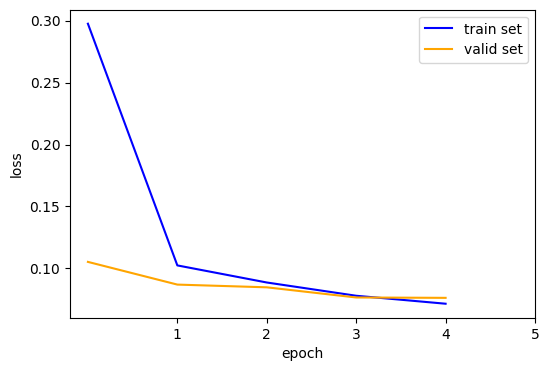

Epoch 4 (17.61s): Train loss =  0.0715  Valid loss =  0.0762


In [185]:
class SelfTaughtResWide(nn.Module):
    def __init__(self, cat_vocab_size, text_vocab_size, emb_dim_text=64, emb_dim_cat=16):
        super(SelfTaughtResWide, self).__init__()
        
        self.cat_embeddings = nn.ModuleList([nn.Embedding(num_embeddings=size, embedding_dim=emb_dim_cat, padding_idx=0) for size in cat_vocab_size])
        self.text_embeddings = nn.Embedding(num_embeddings=text_vocab_size, embedding_dim=emb_dim_text, padding_idx=0)

        input_dim = len(cat_vocab_size) * emb_dim_cat + emb_dim_text 

        self.fc1 = nn.Linear(input_dim, 512) 
        self.relu1 = nn.ReLU()

        self.res1 = ResidualBlock(512) 
        self.res2 = ResidualBlock(512)
        self.res3 = ResidualBlock(512)


        self.fc2 = nn.Linear(512, 256) 
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(256, 128)
        self.relu3 = nn.ReLU()
        self.out = nn.Linear(128,1) 

    def forward(self, x_cat, x_text):
        emb_cat = [layer(x_cat[:,i]) for i,layer in enumerate(self.cat_embeddings)]     
        emb_cat = torch.cat(emb_cat, dim=1)                                             
        emb_text = self.text_embeddings(x_text)                                         
        mean_emb_text = torch.mean(emb_text, dim=1)                                     
        emb_combined = torch.cat([emb_cat, mean_emb_text], dim=1)                       

        x = self.relu1(self.fc1(emb_combined))
        
        x = self.res1(x)
        x = self.res2(x)
        x = self.res3(x)
        
        x = self.relu2(self.fc2(x))
        x = self.relu3(self.fc3(x))
        
        return self.out(x)
    
model_st_res_wide = SelfTaughtResWide(vocab_size, len(word_to_id))
model_st_res_wide, train_lost_st_wide, valid_loss_st_wide, valid_mae_st_wide, duration_st_res_wide = fit_text(model_st_res_wide, train_loader, valid_loader, epochs=5, patience=4)

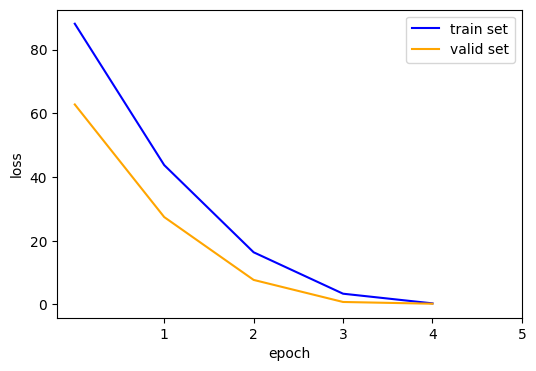

Epoch 4 (10.954s): Train loss =  0.35  Valid loss =  0.2391


In [184]:
class SelfTaughtResSlim(nn.Module):
    def __init__(self, cat_vocab_size, text_vocab_size, emb_dim_text=64, emb_dim_cat=16):
        super(SelfTaughtResSlim, self).__init__()
        
        self.cat_embeddings = nn.ModuleList([nn.Embedding(num_embeddings=size, embedding_dim=emb_dim_cat, padding_idx=0) for size in cat_vocab_size])
        self.text_embeddings = nn.Embedding(num_embeddings=text_vocab_size, embedding_dim=emb_dim_text, padding_idx=0)

        input_dim = len(cat_vocab_size) * emb_dim_cat + emb_dim_text 

        self.fc1 = nn.Linear(input_dim, 64) 
        self.relu1 = nn.ReLU()

        self.res1 = ResidualBlock(64) 
        self.res2 = ResidualBlock(64)
        self.res3 = ResidualBlock(64)


        self.fc2 = nn.Linear(64, 16) 
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(16, 4)
        self.relu3 = nn.ReLU()
        self.out = nn.Linear(4,1) 

    def forward(self, x_cat, x_text):
        emb_cat = [layer(x_cat[:,i]) for i,layer in enumerate(self.cat_embeddings)]     
        emb_cat = torch.cat(emb_cat, dim=1)                                             
        emb_text = self.text_embeddings(x_text)                                         
        mean_emb_text = torch.mean(emb_text, dim=1)                                     
        emb_combined = torch.cat([emb_cat, mean_emb_text], dim=1)                       

        x = self.relu1(self.fc1(emb_combined))
        
        x = self.res1(x)
        x = self.res2(x)
        x = self.res3(x)
        
        x = self.relu2(self.fc2(x))
        x = self.relu3(self.fc3(x))
        
        return self.out(x)
    
model_st_res_slim = SelfTaughtResSlim(vocab_size, len(word_to_id))
model_st_res_slim, train_lost_st_slim, valid_loss_st_slim, valid_mae_st_slim, duration_st_res_slim = fit_text(model_st_res_slim, train_loader, valid_loader, epochs=5, patience=4)

## 4. Results

### 4.1 Results on validation set

In [217]:
valid_loses = np.array([valid_loss_baseline[:5],valid_loss_st[:5],valid_loss_w1[:5],  valid_loss_w2[:5], val_loss_w3[:5], valid_loss_st_conv[:5], valid_loss_st_res[:5], valid_loss_st_2r[:5], valid_loss_res3[:5], val_loss_4r_d[:5], val_loss_batch_d[:5], val_loss_w2_conv_rest[:5], val_loss_w3_att[:5], val_loss_w2_att[:5], valid_loss_w1_rare, valid_loss_w1_rare_3r, valid_loss_res6[:5], valid_loss_st_wide[:5], valid_loss_st_slim[:5]])
model_names = np.array(['Baseline', 'Self-tought', 'Way1', 'Way2', 'Way3', 'Self-Tougth(Conv)', 'Self-Tought(Res)', 'Self-Tought(conv+2xres)', 'Self-Tought(3xres)', 'Way3(4xres+drop)', 'Way(Batch+drop)', 'Way2(Conv+res)', 'Way3(Att)', 'Way2(Att)', 'Way1(rare)', 'Way1(rare+3xres)', 'Self-tought(6xres)', 'Self-tought(wide)', 'Self-tought(slim)'])

df_valid_results = pd.DataFrame(
    data=np.round(valid_loses,3), 
    index=model_names, 
    columns=['Epoch 0', 'Epoch 1', 'Epoch 2', 'Epoch 3', 'Epoch 4']
)
df_valid_results

,Epoch 0,Epoch 1,Epoch 2,Epoch 3,Epoch 4
Baseline,0.166,0.152,0.146,0.202,0.173
Self-tought,0.098,0.083,0.078,0.075,0.073
Way1,0.174,0.164,0.190,0.155,0.168
Way2,0.141,0.115,0.110,0.119,0.117
Way3,0.121,0.104,0.099,0.108,0.086
Self-Tougth(Conv),0.119,0.106,0.082,0.094,0.073
Self-Tought(Res),0.097,0.129,0.083,0.078,0.077
Self-Tought(conv+2xres),0.114,0.100,0.089,0.082,0.082
Self-Tought(3xres),0.109,0.084,0.089,0.092,0.074
Way3(4xres+drop),0.127,0.112,0.107,0.117,0.090


In [134]:
for i in range(len(valid_loses)):
    print(f"{model_names[i]} best score:    {round(np.min(valid_loses[i]),4)}")

Baseline best score:    0.1463
Self-tought best score:    0.0754
Way1 best score:    0.1365
Way2 best score:    0.102
Way3 best score:    0.0913
Self-Tougth(Conv) best score:    0.0738
Self-Tought(Res) best score:    0.0775
Self-Tought(conv+2xres) best score:    0.0773
Self-Tought(3xres) best score:    0.076
Way3(4xres+drop) best score:    0.0956
Way(Batch+drop) best score:    0.0893
Way3(Conv+res) best score:    0.0794
Way2(Conv+res) best score:    0.0847
Way3(Att) best score:    0.0797
Way2(Att) best score:    0.0849
Way1(rare) best score:    0.137
Way1(rare+3xres) best score:    0.1403
Self-tought(6xres) best score:    0.0666
Self-tought(wide) best score:    0.0852
Self-tought(slim) best score:    0.0736


### 4.2 Results on test set

In [135]:
def evaluate_test_set(model, test):
    model.eval()  
    sum_loss = 0.0
    sum_mae = 0.0
    device="cpu"
    loss=nn.MSELoss()
    
    with torch.no_grad():
        for batch_x_cat, batch_x_text, batch_y in test:
            batch_x_cat, batch_x_text, batch_y = batch_x_cat.to(device), batch_x_text.to(device), batch_y.to(device)
            preds = model(batch_x_cat, batch_x_text)
            l = loss(preds.view(-1), batch_y.view(-1))
            sum_loss += l.item() * batch_x_cat.size(0)

            preds_no_log = torch.expm1(preds.view(-1))
            y_real = torch.expm1(batch_y.view(-1))
            mae = torch.abs(y_real - preds_no_log).mean() * batch_x_cat.size(0)
            sum_mae += mae.item()

    final_loss = sum_loss / len(test.dataset)
    final_mae= sum_mae / len(test.dataset)
            
    return final_loss, final_mae

In [ ]:
# baseline
sum_loss = 0
sum_mae = 0

with torch.no_grad():
        for batch_x, batch_y in test_loader_cat:
            preds = baseline(batch_x)
            loss = nn.MSELoss()
            l = loss(preds.view(-1), batch_y.view(-1))
            sum_loss += l.item() * batch_x.size(0)

            preds_no_log = torch.expm1(preds.view(-1))
            y_real = torch.expm1(batch_y.view(-1))
            mae = torch.abs(y_real - preds_no_log).mean() * batch_x.size(0)
            sum_mae += mae.item()

baseline_final_rmsle = sum_loss / len(test_loader_cat.dataset)
baseline_final_mae = sum_mae / len(test_loader_cat.dataset)
baseline_final_rmsle, baseline_final_mae

(0.1323643043986108, 9323.447084252564)

In [225]:
model_list = [baseline, model_st, model_way1, model_way2, model_way3, model_st_conv, model_st_res, model_st_conv_res, model_st_res3, model_way3_4r_d, model_way3_batch, model_way2_conv_rest, model_way3_att, model_way2_att, model_way1_rare, model_way1_rare_3r, model_st_res6, model_st_res_wide, model_st_res_slim]
rmsle_list = [baseline_final_rmsle]
mae_list = [baseline_final_mae]
for i in range(1, len(model_list)):
    if i == 2:
        loader = test_loader_w1
    elif i == 14 or i == 15:
        loader = test_loader_w1_rare
    else:
        loader = test_loader
    rmsle, mae = evaluate_test_set(model_list[i], loader)
    rmsle_list.append(rmsle)
    mae_list.append(mae)

In [227]:
df_results_test = pd.DataFrame({
    'Model': model_names,
    'RMSLE': rmsle_list,
    'MAE': mae_list
})

round(df_results_test.sort_values(by="RMSLE"),3)

,Model,RMSLE,MAE
16,Self-tought(6xres),0.0670,6513.3160
5,Self-Tougth(Conv),0.0730,6920.7210
1,Self-tought,0.0740,6969.9830
8,Self-Tought(3xres),0.0740,6978.4850
17,Self-tought(wide),0.0770,7258.5090
6,Self-Tought(Res),0.0780,7288.1810
7,Self-Tought(conv+2xres),0.0810,7249.8240
13,Way2(Att),0.0840,7566.4160
11,Way2(Conv+res),0.0850,7628.6750
4,Way3,0.0880,7629.1140


### 4.3 Number of parameters

In [226]:
num_params = []

for model in (model_list):
    num_params.append(sum(p.numel() for p in model.parameters() if p.requires_grad))

df_num_params = pd.DataFrame({'Model': model_names, 'num_params': num_params})
df_num_params.sort_values(by="num_params")

,Model,num_params
0,Baseline,362241
2,Way1,400641
3,Way2,400641
14,Way1(rare),400641
11,Way2(Conv+res),441595
15,Way1(rare+3xres),499713
13,Way2(Att),514190
1,Self-tought,2497345
5,Self-Tougth(Conv),2499425
18,Self-tought(slim),2504825


### 4.4 Training time

In [ ]:
durations = [duration_baseline, duration_st, duration_way1, duration_way2, duration_way3, duration_st_conv, duration_st_res, duration_st_conv_res, duration_st_res3, duration_way3_4r_d, duration_way3_batch, duration_way2_conv_rest, duration_way3_att, duration_way2_att, duration_way1_rare, duration_way1_rare_3r, duration_st_res6, duration_st_res_wide, duration_st_res_slim]
durations_sum = [np.sum(times) for times in durations]
df_train_time = pd.DataFrame({'Model': model_names, 'Mean training time': durations_sum})
df_train_time

,Model,Mean training time
0,Baseline,2.532014
1,Self-tought,9.258770
2,Way1,3.274294
3,Way2,6.798059
4,Way3,30.671545
5,Self-Tougth(Conv),320.125564
6,Self-Tought(Res),9.166779
7,Self-Tought(conv+2xres),78.443922
8,Self-Tought(3xres),12.958444
9,Way3(4xres+drop),32.261548


### 4.5 Statistical testing 

In [ ]:
# without baseline
# H0: There is no siginificant differnce between models' performance
# H1: There is significant differnece betweend models' performance

n = len(model_list) - 1
results = np.zeros((10, n)) 

indices = np.arange(len(test_dataset))
np.random.shuffle(indices)
chunks = np.array_split(indices, 10)

for m_idx, model in enumerate(model_list[1:]):
    for b_idx, chunk in enumerate(chunks):
        subset = Subset(test_dataset, chunk)
        
        temp_loader = DataLoader(subset, batch_size=32, shuffle=False)
        
        rmsle, mae = evaluate_test_set(model, temp_loader)
        
        results[b_idx, m_idx] = rmsle 

stat, p = friedmanchisquare(*results.T)
print(f"P-value: {p:.4f}")

# We reject null hypothesis, there is significant differnce bewteen dmoels

P-value: 0.0000


In [ ]:
p_values = scikit_posthocs.posthoc_nemenyi_friedman(results)

p_values.columns = model_names[1:]
p_values.index = model_names[1:]

p_values = pd.DataFrame(p_values)
p_values

,Self-tought,Way1,Way2,Way3,Self-Tougth(Conv),Self-Tought(Res),Self-Tought(conv+2xres),Self-Tought(3xres),Way3(4xres+drop),Way(Batch+drop),Way2(Conv+res),Way3(Att),Way2(Att),Way1(rare),Way1(rare+3xres),Self-tought(6xres),Self-tought(wide),Self-tought(slim)
Self-tought,1.0000,0.0000,0.0006,0.2579,1.0000,0.9995,0.9903,1.0000,0.0102,0.0343,0.6176,0.0190,0.7112,0.0000,0.0000,1.0000,1.0000,0.0001
Way1,0.0000,1.0000,0.9713,0.0677,0.0000,0.0000,0.0003,0.0000,0.6495,0.3939,0.0119,0.5200,0.0073,1.0000,1.0000,0.0000,0.0000,0.9988
Way2,0.0006,0.9713,1.0000,0.9637,0.0002,0.0594,0.1557,0.0031,1.0000,0.9999,0.7405,1.0000,0.6495,1.0000,0.9988,0.0000,0.0297,1.0000
Way3,0.2579,0.0677,0.9637,1.0000,0.1394,0.9637,0.9963,0.5200,0.9999,1.0000,1.0000,1.0000,1.0000,0.4877,0.2128,0.0222,0.9020,0.7951
Self-Tougth(Conv),1.0000,0.0000,0.0002,0.1394,1.0000,0.9948,0.9547,1.0000,0.0037,0.0140,0.4244,0.0073,0.5200,0.0000,0.0000,1.0000,0.9992,0.0000
Self-Tought(Res),0.9995,0.0000,0.0594,0.9637,0.9948,1.0000,1.0000,1.0000,0.3359,0.5852,0.9992,0.4557,0.9998,0.0026,0.0004,0.8647,1.0000,0.0140
Self-Tought(conv+2xres),0.9903,0.0003,0.1557,0.9963,0.9547,1.0000,1.0000,0.9997,0.5852,0.8201,1.0000,0.7112,1.0000,0.0102,0.0018,0.6495,1.0000,0.0454
Self-Tought(3xres),1.0000,0.0000,0.0031,0.5200,1.0000,1.0000,0.9997,1.0000,0.0395,0.1109,0.8647,0.0677,0.9178,0.0001,0.0000,0.9992,1.0000,0.0005
Way3(4xres+drop),0.0102,0.6495,1.0000,0.9999,0.0037,0.3359,0.5852,0.0395,1.0000,1.0000,0.9869,1.0000,0.9713,0.9903,0.9020,0.0003,0.2128,0.9998
Way(Batch+drop),0.0343,0.3939,0.9999,1.0000,0.0140,0.5852,0.8201,0.1109,1.0000,1.0000,0.9992,1.0000,0.9975,0.9318,0.7112,0.0012,0.4244,0.9948


### Conclusion

The best results on the test set were achieved by the self-taught model with 6 residual blocks, the self-taught model with Conv1D, and the baseline self-taught model, respectively. While global testing indicated significant performance differences across all evaluated models, post-hoc analysis revealed no statistically significant differences between the top three. Consequently, the baseline self-taught model was selected as the optimal choice due to its superior efficiency, characterized by the shortest training time and the lowest parameter count.

### Error analuysis

In [282]:
def evaluate_and_get_data(model, loader):
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    
    all_preds = []
    all_actuals = []
    
    with torch.no_grad():
        for batch_x_cat, batch_x_text, batch_y in loader:
            batch_x_cat = batch_x_cat.to(device)
            batch_x_text = batch_x_text.to(device)
            batch_y = batch_y.to(device)
            preds = model(batch_x_cat, batch_x_text)
            preds_real = torch.expm1(preds.view(-1)).cpu().numpy()
            actuals_real = torch.expm1(batch_y.view(-1)).cpu().numpy()
            
            all_preds.extend(preds_real)
            all_actuals.extend(actuals_real)
            
    return np.array(all_actuals), np.array(all_preds)
actuals_log, preds = evaluate_and_get_data(model_st, test_loader)
analysis_df = df_final.loc[x_test.index].copy()
analysis_df['PredictedSalary'] = preds
analysis_df['AbsError'] = np.abs(analysis_df['SalaryNormalized'] - analysis_df['PredictedSalary'])
analysis_df['ErrorRelative'] = (analysis_df['AbsError'] / analysis_df['SalaryNormalized']) * 100
analysis_df.sort_values(by='AbsError', ascending=False).head(10)

,Category,Company,LocationNormalized,ContractType,ContractTime,FullDescription,SalaryNormalized,PredictedSalary,AbsError,ErrorRelative
214389,IT Jobs,Baltic Training Services,Heckmondwike,Missing,permanent,"The ideal candidate will have completed their education and be keen to learn new skills. You will have an excellent eye for detail, with keen observation, together with very good communication skills. You will also need to be both methodical and meticulous as the role involves the careful noting and recording of issues to be found within our applications. The apprenticeship will involve contact with a variety of customers in various sectors, so you will be required to act in a professional manner at all times. If you have had previous experience of dealing with customers that would be a distinct advantage. During the apprenticeship your main duties will involve: Liaising with the development team to test new applications, application improvements or bug fixes Discussing and confirming customer's requirements for applications Writing and following test plans Recording your testing clearly and thoroughly Recording support issues that are reported by customers Undertaking triage of reported issues The above list is not exhaustive and additional duties will be required as the business needs. You will also be given additional duties as your apprenticeship progresses and your knowledge improves. Training to be provided Level 3 Diploma IT Professional Level 3 Advanced Diploma in Systems and Principles Level 2 key skills (Literacy and Numeracy) CISCO IT Essentials MTA (Microsoft Technical Associate certification) For the candidates with the greatest ability and aspirations CompTIA A and MCTS (Microsoft Certified Technology Specialist) may also be offered. Hard working, good work ethic, dependable, willing to work late/work through lunch, smart, intelligent – good with customers, positive attitude. Strong (must be able to lift copiers) Driver – Driving licence would be preferable due to the future progression within the role. Confident Professional Flexible Team Player Ambitious/Drive Excellent time keeping (punctual, organised, manages time effectively) Proactive approach to work Quickly picks up new skills Your goal should be to continuously develop your professional skills and to strive for a permanent role within the company. This job was originally posted as www.totaljobs.com/JobSeeking/ITApprenticeTraineePhotocopyEngineer_job****",190809,11414.63,179394.37,94.02
22932,Accounting & Finance Jobs,Cash Store Uk,Rochdale,full_time,Missing,"Are you an experienced customer/sales advisor looking for a new challenge in a vibrant, successful and growing company? As an advisor for The Cash Store you will be required to maximise sales and improve profitability through the satisfaction and retention of customers. You will generate new customers by raising the profile of the business, deal with customers in an open, friendly and engaging way, developing trust and enabling you to sell our loans and services. You will process loan applications according to lender guidelines, check references, precall customers when repayments are due and collect repayments on overdue loans. To be successful you will have skills in both facetoface and telephone sales. Experience in a mobile phone outlet or in the alternative finance industry would be an advantage. You will have excellent listening skills, good numeracy, the ability to communicate clearly and have a tactful and discreet telephone manner. Salary is based on **** hours a week, 5 days a week on rota, Monday Saturday. In addition there is profit related variable pay. In additional to our competitive salary, The Cash Store offers a fantastic employee benefits package providing Life Insurance, a Health Cash Plan and an Employee Assistance Programme. There is also an amazing range of money saving benefits including childcare vouchers, retail offers and discounted gym membership. Apply by emailing your

In [ ]:
# actual vs predicted
# residuals vs predicted 
# errors distribution